# Demographic Forecast — BU vs HS Scenario Comparison (2040 / 2050)

Decides whether the two demographic forecast scenarios need **separate demand
matrices**, or whether one matrix can serve both. The forecast files
(`Input/Demographic_Forecast/`, 781 study TAZs each) are:

| File | Meaning |
|---|---|
| `Zonal_2020.csv` | 2020 observed zonal socioeconomics |
| `Zonal_BU_2040.csv` / `Zonal_BU_2050.csv` | **Business as Usual** scenario |
| `Zonal_HS_2040.csv` / `Zonal_HS_2050.csv` | **Housing Strategy** plan scenario |

**Method.** Future matrices are produced the same way the 2022 vintage alignment
works (`Vintage_alignment_2022.ipynb`): the base matrix is Furnessed with per-area
growth margins — `POPULATION` on the origin side, `EMPL_TOT` on the destination side —
computed over the 28 aggregated research areas (`Input/Submatrix_tazs.xlsx`,
205 TAZs, 119 of them the LRT corridor). Two scenarios therefore need two matrices
**iff their per-area growth margins differ materially**; regional totals alone are
irrelevant if the spatial allocation is the same, and vice versa. The comparison is
run at three levels: research-area totals, the 28 aggregated areas (the actual
Furness margin resolution), and individual TAZs.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 220)
FILES = ['2020', 'BU_2040', 'BU_2050', 'HS_2040', 'HS_2050']
zonal = {k: pd.read_csv(f'Input/Demographic_Forecast/Zonal_{k}.csv',
                        encoding='utf-8', encoding_errors='replace') for k in FILES}
sub = pd.read_excel('Input/Submatrix_tazs.xlsx')          # 205 research-area TAZs
taz_area = sub.set_index('TAZ')[['AggAreaCode', 'AggAreaName', 'IsLRT_Corridor']]
legend = (sub.groupby('AggAreaCode')
             .agg(AggAreaName=('AggAreaName', 'first'), n_TAZs=('TAZ', 'size'),
                  corridor_TAZs=('IsLRT_Corridor', 'sum')))

base_ids = set(zonal['2020'].TAZ_ID)
for k, z in zonal.items():
    assert set(z.TAZ_ID) == base_ids and not z.TAZ_ID.duplicated().any(), k
assert not (set(sub.TAZ) - base_ids), 'research-area TAZ missing from zonal files'
print(f'{len(base_ids)} TAZs in every file, identical TAZ set; '
      f'all {len(sub)} research-area TAZs covered')

781 TAZs in every file, identical TAZ set; all 205 research-area TAZs covered


## 1. Totals — the scenarios agree on *how much* growth

Zone classes: **LRT Corridor** (119 TAZs), **research non-corridor** (86 TAZs, the
rest of the 205), and the rest of the 781-TAZ study system.

In [2]:
def classify(df):
    d = df.merge(taz_area, left_on='TAZ_ID', right_index=True, how='left')
    return np.where(d.AggAreaCode.notna(),
                    np.where(d.IsLRT_Corridor == 1, '1 LRT Corridor', '2 Research non-corridor'),
                    '3 Rest of study area')

rows = []
for k, df in zonal.items():
    g = df.groupby(classify(df))[['POPULATION', 'EMPL_TOT']].sum()
    g.loc['4 Research area (205 TAZ)'] = g.loc[['1 LRT Corridor', '2 Research non-corridor']].sum()
    g.loc['5 Whole study (781 TAZ)'] = df[['POPULATION', 'EMPL_TOT']].sum().values
    for cls, r in g.iterrows():
        rows.append({'zone_class': cls, 'file': k, 'POP': r.POPULATION, 'EMPL': r.EMPL_TOT})
totals = pd.DataFrame(rows).pivot(index='zone_class', columns='file', values=['POP', 'EMPL'])
for v in ['POP', 'EMPL']:
    for yr in ['2040', '2050']:
        totals[(v, f'HS/BU_{yr}_%')] = (totals[(v, f'HS_{yr}')] / totals[(v, f'BU_{yr}')] - 1) * 100
totals = totals.sort_index(axis=1, level=0)
os.makedirs('Output/demographics', exist_ok=True)
totals.round(1).to_csv('Output/demographics/scenario_totals_by_class.csv')
print(totals.round(1).to_string())

                             EMPL                                                                    POP                                                              
file                         2020  BU_2040  BU_2050 HS/BU_2040_% HS/BU_2050_%  HS_2040  HS_2050     2020  BU_2040  BU_2050 HS/BU_2040_% HS/BU_2050_%  HS_2040  HS_2050
zone_class                                                                                                                                                            
1 LRT Corridor             165344   220719   253524          1.5          5.7   224052   267972   222117   316404   389835          0.7          0.2   318465   390730
2 Research non-corridor     68690    95323   112097          8.9          8.3   103842   121420   206115   277781   314355          5.4          9.0   292676   342755
3 Rest of study area       719628  1096981  1294443          3.2          6.7  1131709  1381583  2128252  2835734  3236445          4.9          9.8  2975422  355293

Corridor-wide, the scenarios are near-identical on population (HS/BU **+0.7%** in
2040, **+0.2%** in 2050) and modest on employment (+1.5% / +5.7%). If this were the
whole story one matrix would do. It is not — the agreement in totals hides opposite
spatial allocations.

## 2. Per-area growth margins — the scenarios disagree on *where* it goes

Growth factors `g = X_scenario / X_2020` per aggregated area, exactly the quantities
that become Furness margins. `dP` / `dE` = HS-to-BU ratio minus 1 (%), i.e. how far
apart the two scenarios' margins are. Pure-employment areas (2020 population < 500:
Namal, Hutzot, Kiryat Nahum, Hamifrats, Matam, Haifa Airport) take the employment
factor on the origin side in the pipeline, so their population ratios are shown as
NaN where undefined; absolute differences still matter and are shown in §3.

In [3]:
agg = {}
for k, z in zonal.items():
    a = z.groupby(z.TAZ_ID.map(taz_area.AggAreaCode))[['POPULATION', 'EMPL_TOT']].sum()
    agg[f'p_{k}'], agg[f'e_{k}'] = a.POPULATION, a.EMPL_TOT
f = pd.DataFrame(agg)
f.index = f.index.astype(int)
f.index.name = 'AggAreaCode'

area = legend.join(f)
area['IsLRT_Corridor'] = np.select(
    [area.corridor_TAZs == area.n_TAZs, area.corridor_TAZs == 0], [1, 0], -1)
tbl = area[['AggAreaName', 'IsLRT_Corridor']].copy()
tbl['p2020'], tbl['e2020'] = area.p_2020.astype(int), area.e_2020.astype(int)
for yr in ['2040', '2050']:
    y = yr[2:]
    with np.errstate(divide='ignore', invalid='ignore'):
        tbl[f'gP_BU{y}'] = np.where(area.p_2020 > 0, area[f'p_BU_{yr}'] / area.p_2020, np.nan)
        tbl[f'gP_HS{y}'] = np.where(area.p_2020 > 0, area[f'p_HS_{yr}'] / area.p_2020, np.nan)
        tbl[f'dP{y}_%'] = np.where(area[f'p_BU_{yr}'] > 0,
                                   (area[f'p_HS_{yr}'] / area[f'p_BU_{yr}'] - 1) * 100, np.nan)
        tbl[f'gE_BU{y}'] = area[f'e_BU_{yr}'] / area.e_2020
        tbl[f'gE_HS{y}'] = area[f'e_HS_{yr}'] / area.e_2020
        tbl[f'dE{y}_%'] = (area[f'e_HS_{yr}'] / area[f'e_BU_{yr}'] - 1) * 100
    tbl[f'dPabs{y}'] = (area[f'p_HS_{yr}'] - area[f'p_BU_{yr}']).astype(int)
    tbl[f'dEabs{y}'] = (area[f'e_HS_{yr}'] - area[f'e_BU_{yr}']).astype(int)
tbl.round(3).to_csv('Output/demographics/scenario_comparison_area.csv')
show = ['AggAreaName', 'IsLRT_Corridor', 'p2020', 'gP_BU50', 'gP_HS50', 'dP50_%',
        'e2020', 'gE_BU50', 'gE_HS50', 'dE50_%']
print(tbl[show].round(2).to_string())

for yr in ['40', '50']:
    m = tbl.p2020 >= 500
    n_big = (tbl.loc[m, f'dP{yr}_%'].abs() > 10).sum()
    print(f'20{yr}: {n_big} of {m.sum()} populated areas (2020 pop>=500) have '
          f'population margins differing by >10% between scenarios '
          f'(employment: {(tbl[f"dE{yr}_%"].abs() > 10).sum()} of {len(tbl)})')

                       AggAreaName  IsLRT_Corridor   p2020  gP_BU50  gP_HS50   dP50_%  e2020  gE_BU50  gE_HS50  dE50_%
AggAreaCode                                                                                                           
1                      TiratCarmel               1   24681     4.87     1.56   -67.90   7744     3.48     1.63  -53.27
2                            Matam               1     390     1.07    24.83  2216.75  14621     1.29     1.29    0.00
3                       Neot Peres               1    4211     0.92     3.29   256.45   6778     1.53     1.95   27.39
4                       Neve David               1   14578     0.90     1.21    35.05   2160     0.92     1.28   38.98
5                        Ein Hayam               1    6021     1.10     1.31    19.52    762     1.14     1.45   27.39
6                        Bat Galim               1    4729     0.96     1.89    97.41   8611     1.13     1.42   25.24
7                   Kiryat Eliezer              

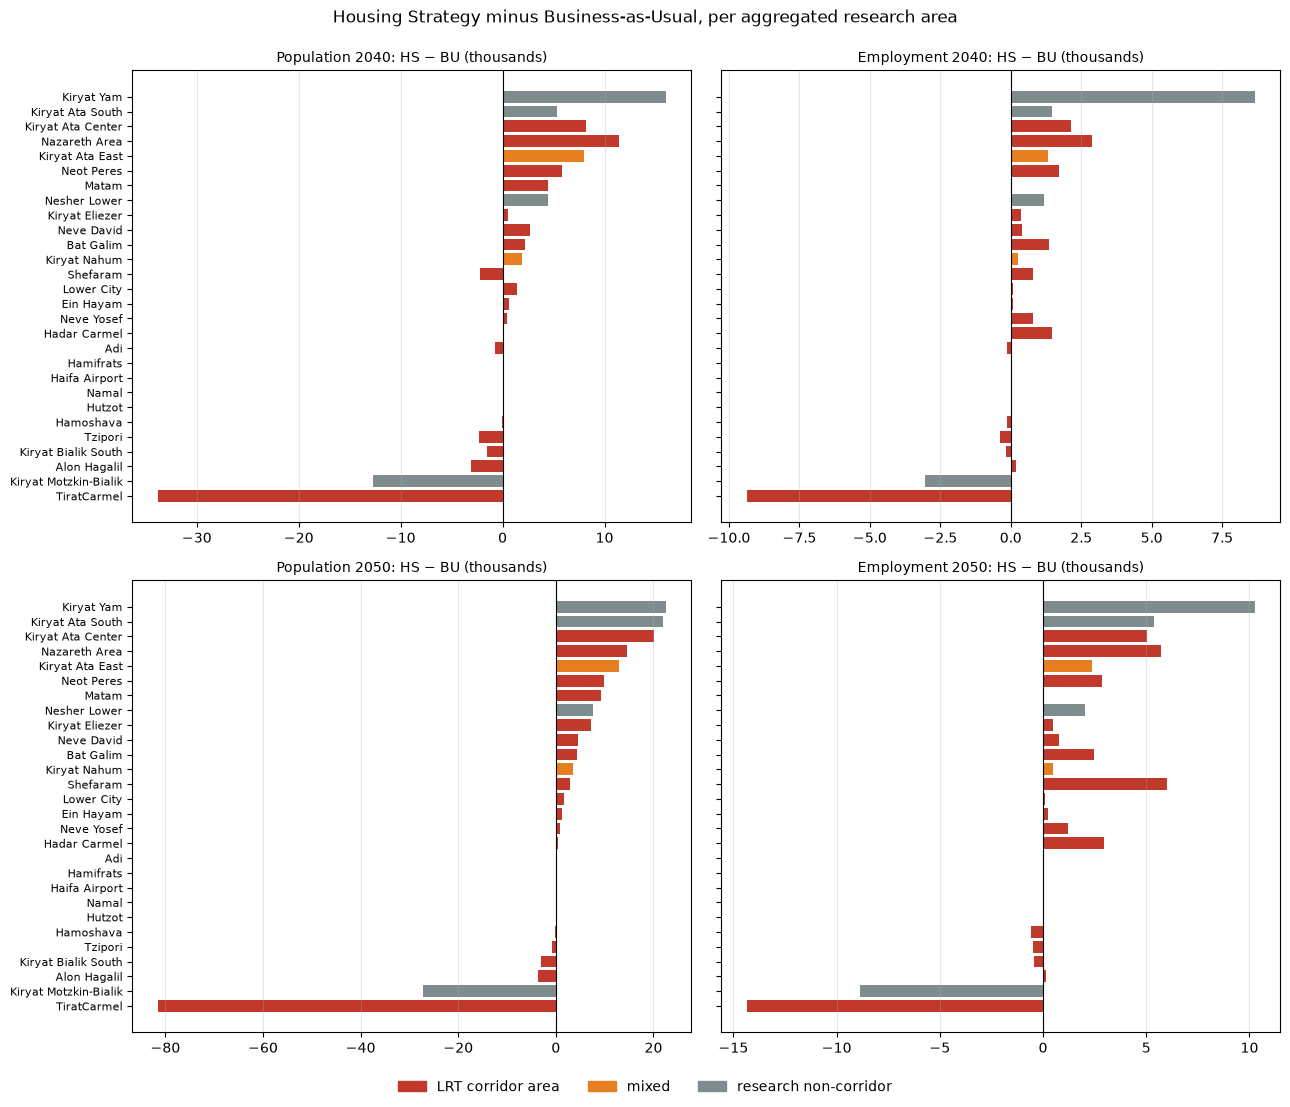

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11), sharey=True)
order = tbl.sort_values('dPabs50').index
colors = {1: '#c0392b', -1: '#e67e22', 0: '#7f8c8d'}
bar_c = [colors[c] for c in tbl.loc[order, 'IsLRT_Corridor']]
for j, (col, ttl) in enumerate([('dPabs', 'Population'), ('dEabs', 'Employment')]):
    for i, yr in enumerate(['40', '50']):
        ax = axes[i, j]
        ax.barh(range(len(order)), tbl.loc[order, f'{col}{yr}'] / 1000, color=bar_c)
        ax.set_yticks(range(len(order)))
        ax.set_yticklabels(tbl.loc[order, 'AggAreaName'], fontsize=8)
        ax.axvline(0, color='k', lw=0.8)
        ax.set_title(f'{ttl} 20{yr}: HS − BU (thousands)', fontsize=10)
        ax.grid(axis='x', alpha=0.3)
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=colors[1], label='LRT corridor area'),
                    Patch(color=colors[-1], label='mixed'),
                    Patch(color=colors[0], label='research non-corridor')],
           loc='lower center', ncol=3, frameon=False)
fig.suptitle('Housing Strategy minus Business-as-Usual, per aggregated research area', y=0.995)
fig.tight_layout(rect=[0, 0.03, 1, 1])
fig.savefig('Output/figures/scenario_BU_vs_HS_areas.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. TAZ level — divergence inside the research area

In [5]:
taz205 = sub.TAZ.tolist()
for yr in ['2040', '2050']:
    bu = zonal[f'BU_{yr}'].set_index('TAZ_ID').loc[taz205]
    hs = zonal[f'HS_{yr}'].set_index('TAZ_ID').loc[taz205]
    for col, name in [('POPULATION', 'pop'), ('EMPL_TOT', 'empl')]:
        b, h = bu[col], hs[col]
        r = np.corrcoef(b, h)[0, 1]
        m = b > 200
        pct = (h[m] / b[m] - 1) * 100
        print(f'{yr} {name:4s}: TAZ-level r = {r:.3f}; of {m.sum()} TAZs with BU > 200, '
              f'{(pct.abs() > 20).sum()} differ by >20% (median |diff| {pct.abs().median():.0f}%)')

tirat = sub.loc[sub.AggAreaName == 'TiratCarmel', 'TAZ']
print('\nTirat Carmel population, the single largest divergence:')
print(pd.DataFrame({k: zonal[k].set_index('TAZ_ID').POPULATION.loc[tirat].sum()
                    for k in FILES}, index=['total']).to_string())

2040 pop : TAZ-level r = 0.875; of 125 TAZs with BU > 200, 54 differ by >20% (median |diff| 16%)
2040 empl: TAZ-level r = 0.952; of 160 TAZs with BU > 200, 59 differ by >20% (median |diff| 11%)
2050 pop : TAZ-level r = 0.702; of 124 TAZs with BU > 200, 77 differ by >20% (median |diff| 26%)
2050 empl: TAZ-level r = 0.891; of 160 TAZs with BU > 200, 81 differ by >20% (median |diff| 20%)

Tirat Carmel population, the single largest divergence:
        2020  BU_2040  BU_2050  HS_2040  HS_2050
total  24681    70221   120120    36392    38557


## 4. Findings and verdict

The two scenarios describe **the same amount of regional growth put in different
places**. Corridor-wide population differs by well under 1%, yet at the margin
resolution the Furness actually uses, the scenarios diverge drastically, and the
divergence is concentrated in the corridor itself:

- **Tirat Carmel** (corridor's south-western terminus): BU grows it ×4.9 by 2050
  (24.7k → 120.1k residents); HS caps it at ×1.6 (→ 38.6k) — an **82k-person, −68%**
  swing in the single largest corridor anchor.
- **Haifa inner city** absorbs what HS removes from Tirat Carmel: Neot Peres
  (HS ×3.3 vs BU ×0.9), Bat Galim (×1.9 vs ×1.0), Lower City (×2.2 vs ×1.6), and
  new residential population in the Matam/Kiryat Nahum employment districts
  (~9.7k / 3.5k residents where BU keeps ≈ 0).
- **Kiryat Ata** flips the same way: Center ×2.8 vs ×1.3 (+110%), East ×2.4 vs ×1.0.
  Among non-corridor research areas, Kiryat Yam gains +27% population / +52%
  employment under HS while Kiryat Motzkin–Bialik loses −16%.
- By 2050, **18 of 22** populated research areas have population margins differing by
  more than 10% between scenarios; at TAZ level the population correlation drops to
  r = 0.70 and 77 of 124 substantive TAZs differ by more than 20%.

**Verdict: one matrix cannot serve both scenarios.** The growth margins differ by
tens of percent exactly in the areas the LRT serves, and they move demand in opposite
directions along the alignment — BU loads the south-western terminus, HS loads the
urban core and the Kiryat Ata end. A shared matrix would misstate corridor flows for
either scenario. Since each future matrix is just the 2022 base Furnessed with that
scenario-year's margins, the cost of doing it right is four Furness runs instead of
one: **BU-2040, BU-2050, HS-2040, HS-2050** — same procedure, different margin
files. (If a further saving is ever needed, only the *pattern* stage could be shared;
the margins never can.)

**Outputs**: `Output/demographics/scenario_totals_by_class.csv`,
`Output/demographics/scenario_comparison_area.csv`,
`Output/figures/scenario_BU_vs_HS_areas.png`.